In [1]:
# ============================================
# SALES DATA ANALYSIS PROJECT
# Project 1 - Retail Sales Analysis
# ============================================

# Import Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Visualization Style
sns.set_style("whitegrid")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ============================================
# LOAD DATASET
# ============================================

# Load CSV File
df = pd.read_csv('../data/SampleSuperstore.csv')

# Display First 5 Rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
# ============================================
# DATASET OVERVIEW
# ============================================

# Dataset Shape
print("Dataset Shape:", df.shape)

# Column Names
print("\nColumn Names:\n")
print(df.columns)

# Data Types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (9994, 13)

Column Names:

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

Data Types:

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [4]:
# ============================================
# DATA QUALITY CHECK
# ============================================

# Missing Values
print("Missing Values:\n")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Statistical Summary
print("\nStatistical Summary:\n")
print(df.describe())

Missing Values:

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows: 17

Statistical Summary:

        Postal Code         Sales     Quantity     Discount       Profit
count   9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean   55190.379428    229.858001     3.789574     0.156203    28.656896
std    32063.693350    623.245101     2.225110     0.206452   234.260108
min     1040.000000      0.444000     1.000000     0.000000 -6599.978000
25%    23223.000000     17.280000     2.000000     0.000000     1.728750
50%    56430.500000     54.490000     3.000000     0.200000     8.666500
75%    90008.000000    209.940000     5.000000     0.200000    29.364000
max    99301.000000  22638.480000    14.000000     0.800000  8399.976000


In [5]:
# ============================================
# DATA CLEANING
# ============================================

# Dataset Shape Before Cleaning
print("Shape Before Removing Duplicates:", df.shape)

# Remove Duplicate Rows
df = df.drop_duplicates()

# Dataset Shape After Cleaning
print("Shape After Removing Duplicates:", df.shape)

# Verify Duplicate Removal
print("Remaining Duplicate Rows:", df.duplicated().sum())

Shape Before Removing Duplicates: (9994, 13)
Shape After Removing Duplicates: (9977, 13)
Remaining Duplicate Rows: 0


Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


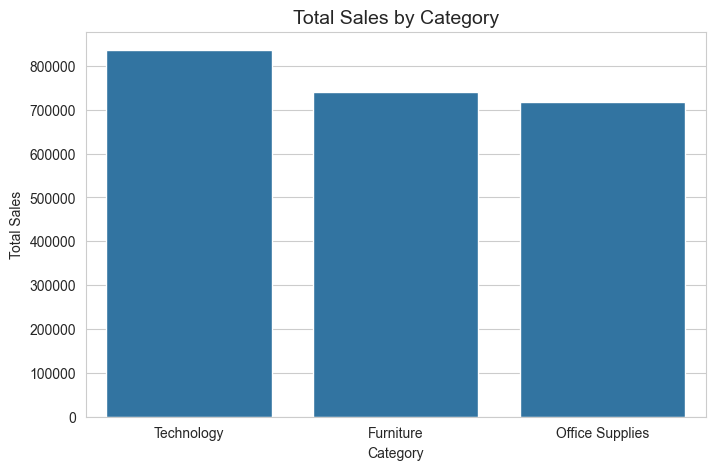

In [6]:
# ============================================
# SALES BY CATEGORY
# ============================================

# Group Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Print Values
print(category_sales)

# Create Bar Chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

# Chart Title and Labels
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Show Chart
plt.show()

In [7]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64


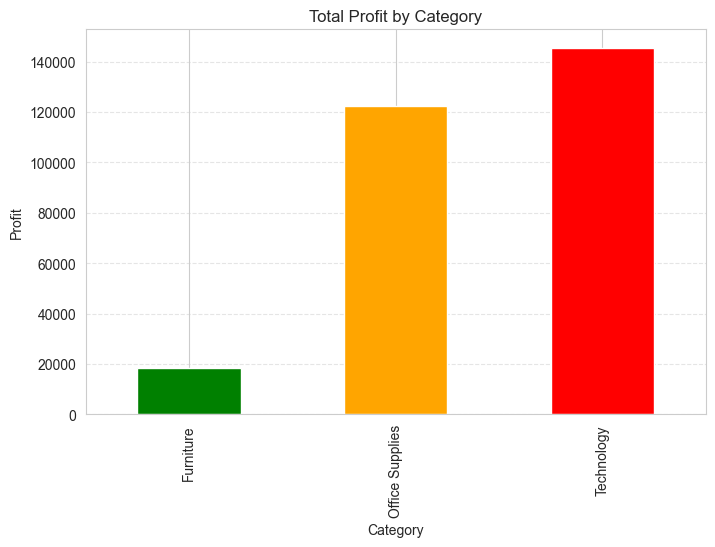

In [8]:
plt.figure(figsize=(8,5))

category_profit.plot(
    kind='bar',
    color=['green', 'orange', 'red']
)

plt.title("Total Profit by Category")

plt.xlabel("Category")
plt.ylabel("Profit")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Profit Analysis by Category

- Technology category generated both the highest sales and highest profit.
- Office Supplies maintained strong profitability with moderate sales.
- Furniture showed high sales volume but extremely low profit margins, indicating potential issues with discounts, shipping costs, or operational expenses.
- The analysis highlights that high sales do not necessarily translate into high profitability.

In [9]:
profit_margin = (
    df.groupby('Category')['Profit'].sum()
    /
    df.groupby('Category')['Sales'].sum()
) * 100

print(profit_margin)

Category
Furniture           2.485047
Office Supplies    17.024998
Technology         17.395712
dtype: float64


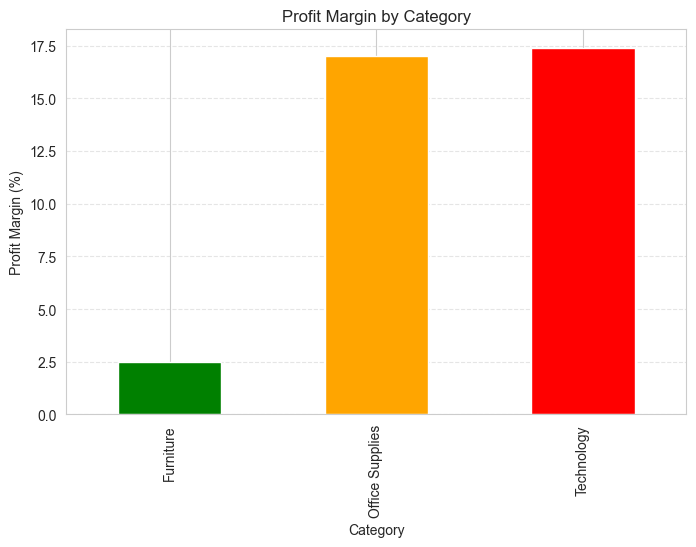

In [10]:
plt.figure(figsize=(8,5))

profit_margin.plot(
    kind='bar',
    color=['green', 'orange', 'red']
)

plt.title("Profit Margin by Category")

plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Profit Margin Insights

- Technology achieved the highest profit margin, making it the most profitable and efficient category.
- Office Supplies also maintained strong profitability with stable margins.
- Furniture generated high sales revenue but showed an extremely low profit margin of only 2.48%.
- The Furniture category may be suffering from excessive discounts, high shipping costs, or operational inefficiencies.
- This analysis highlights that high sales volume does not necessarily result in high profitability.

In [11]:
subcat_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(subcat_sales)

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64


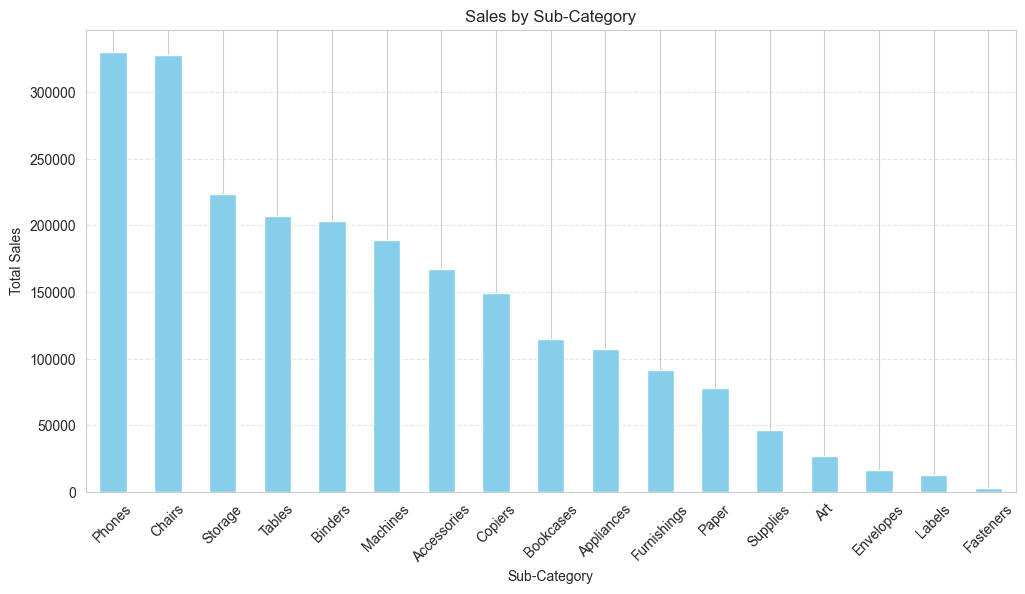

In [12]:
plt.figure(figsize=(12,6))

subcat_sales.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Sales by Sub-Category")

plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Sales Analysis by Sub-Category

- Phones generated the highest sales among all sub-categories.
- Chairs and Tables also contributed significantly to total sales.
- Storage and Binders showed stable sales performance.
- Fasteners, Labels, and Envelopes contributed the least to overall revenue.
- High sales in Furniture-related sub-categories may not necessarily indicate high profitability and require further profit analysis.

In [13]:
subcat_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(subcat_profit)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


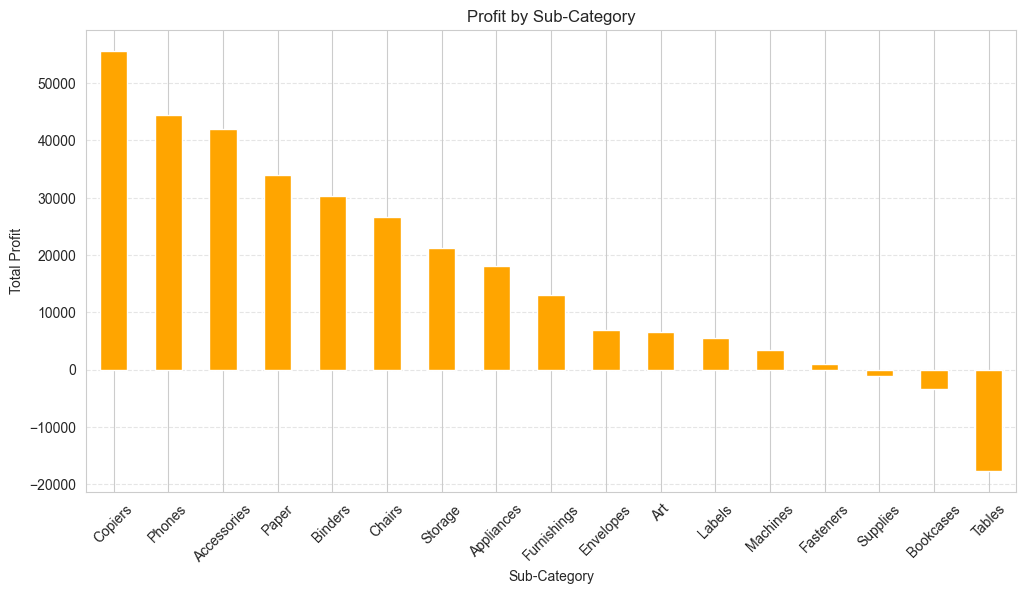

In [14]:
plt.figure(figsize=(12,6))

subcat_profit.plot(
    kind='bar',
    color='orange'
)

plt.title("Profit by Sub-Category")

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Profit Analysis by Sub-Category

- Copiers generated the highest overall profit among all sub-categories.
- Phones and Accessories also delivered strong profitability with high sales performance.
- Tables emerged as the biggest loss-making sub-category despite generating high sales revenue.
- Bookcases and Supplies also showed negative profitability.
- The analysis reveals that some high-revenue products may still negatively impact overall business profitability.
- Furniture-related products appear to suffer from operational inefficiencies or excessive discounting.


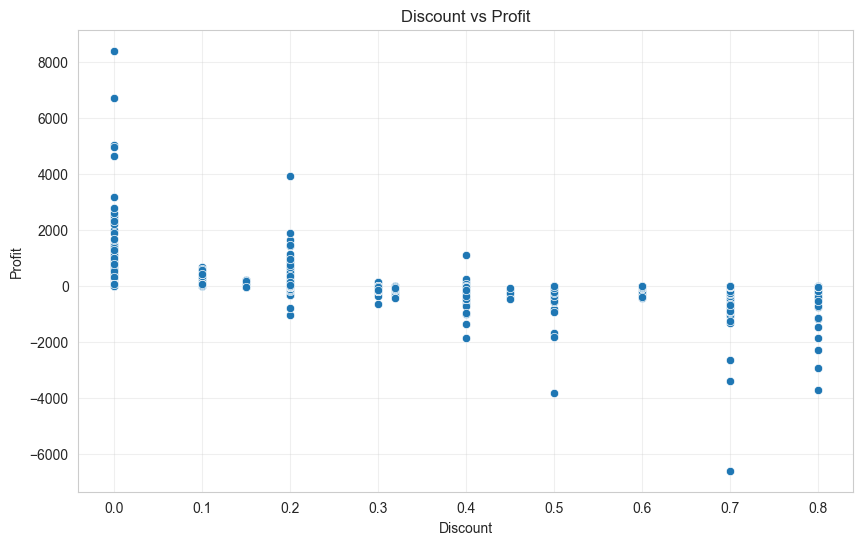

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

In [16]:
correlation = df[['Discount', 'Profit']].corr()

print(correlation)

          Discount    Profit
Discount  1.000000 -0.219662
Profit   -0.219662  1.000000


## Discount vs Profit Analysis

- A negative correlation (-0.22) exists between Discount and Profit.
- As discount levels increase, profitability generally decreases.
- Higher discount ranges (0.5 to 0.8) show several loss-making transactions.
- Lower discount levels are associated with healthier profit margins.
- Excessive discounting appears to be one of the major causes of losses in certain sub-categories, especially Furniture products.

In [17]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


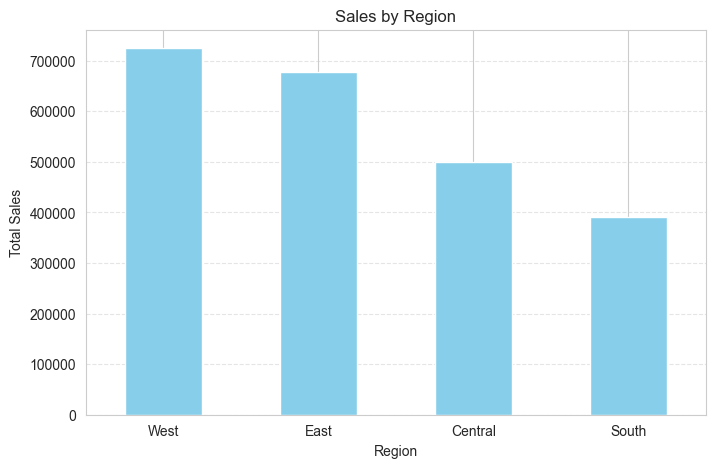

In [18]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Sales by Region")

plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [19]:
region_profit = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


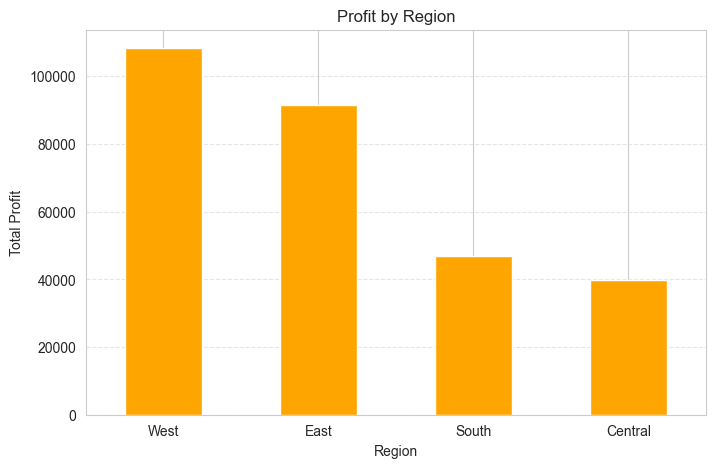

In [20]:
plt.figure(figsize=(8,5))

region_profit.plot(
    kind='bar',
    color='orange'
)

plt.title("Profit by Region")

plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Regional Sales and Profit Analysis

- The West region generated the highest sales and profit, making it the strongest performing market.
- The East region also demonstrated strong profitability with high sales performance.
- Central region showed moderate sales but relatively weak profitability, indicating possible operational inefficiencies or excessive discounting.
- South region generated the lowest sales but maintained better profit efficiency compared to the Central region.
- Regional analysis suggests that profitability performance differs significantly across markets.

In [21]:
top_states = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_states)

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


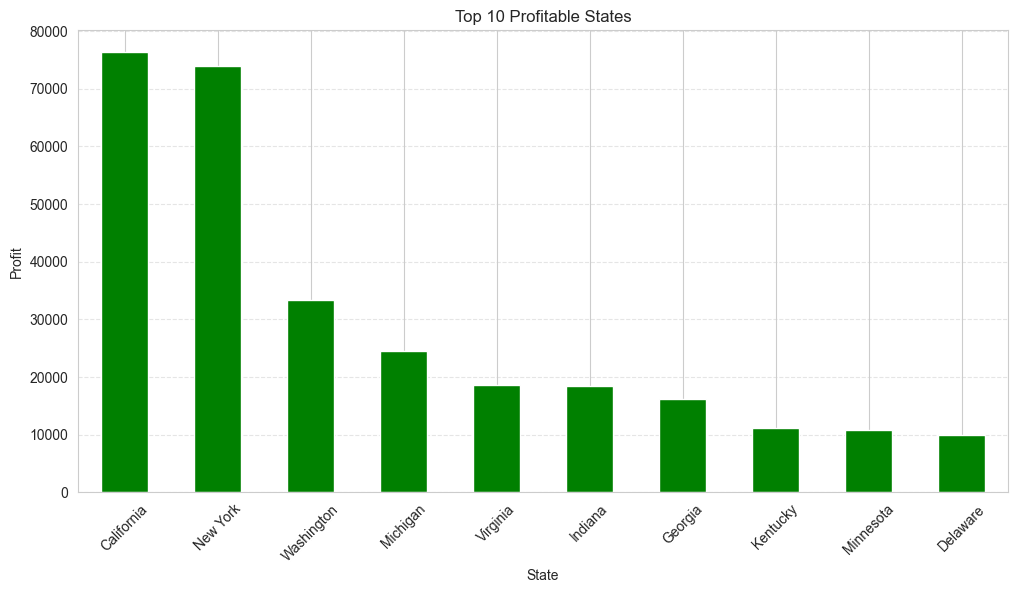

In [22]:
plt.figure(figsize=(12,6))

top_states.plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Profitable States")

plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [23]:
loss_states = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

print(loss_states)

State
Texas            -25750.9833
Ohio             -16959.3178
Pennsylvania     -15565.4035
Illinois         -12601.6500
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1194.0993
Name: Profit, dtype: float64


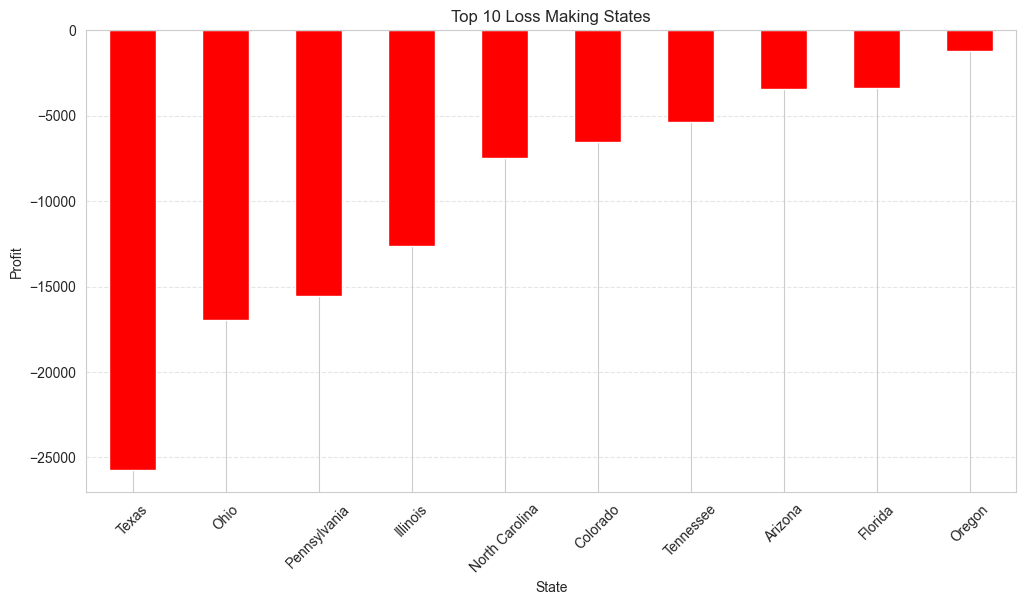

In [24]:
plt.figure(figsize=(12,6))

loss_states.plot(
    kind='bar',
    color='red'
)

plt.title("Top 10 Loss Making States")

plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## State Wise Profit Analysis

- California and New York emerged as the most profitable states.
- Washington and Michigan also demonstrated strong profitability.
- Texas recorded the highest overall loss among all states.
- Ohio, Pennsylvania, and Illinois also showed significant negative profitability.
- The analysis indicates that business performance varies significantly across geographic locations.
- Loss-making states may require pricing optimization, discount control, and operational improvements.

In [25]:
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


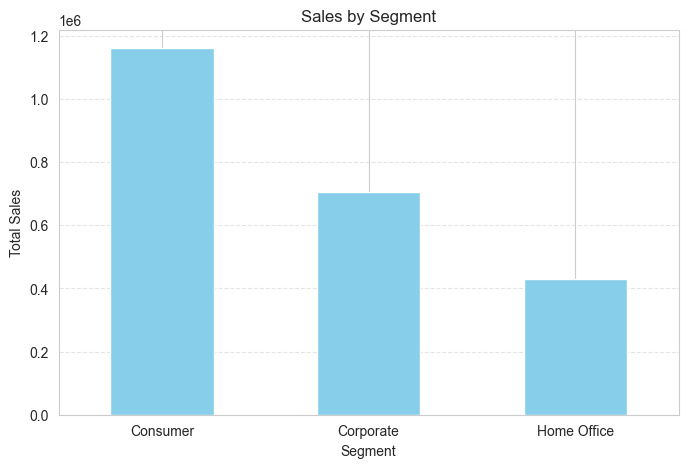

In [26]:
plt.figure(figsize=(8,5))

segment_sales.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Sales by Segment")

plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [27]:
segment_profit = (
    df.groupby('Segment')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(segment_profit)

Segment
Consumer       134007.4413
Corporate       91954.9798
Home Office     60279.0015
Name: Profit, dtype: float64


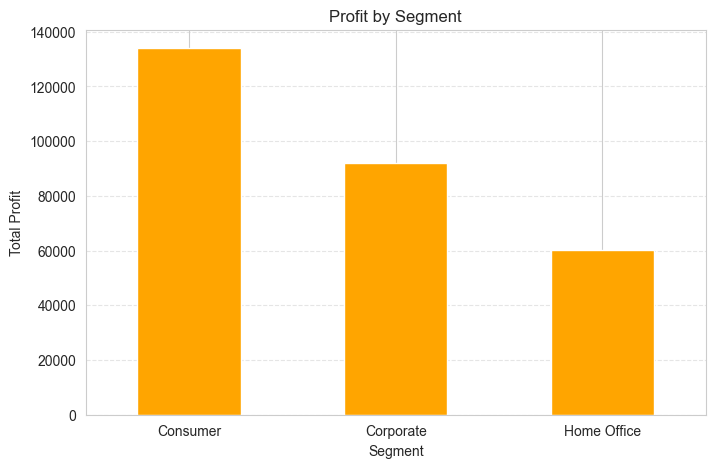

In [28]:
plt.figure(figsize=(8,5))

segment_profit.plot(
    kind='bar',
    color='orange'
)

plt.title("Profit by Segment")

plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Segment Wise Sales and Profit Analysis

- Consumer segment generated the highest sales and profit among all customer segments.
- Corporate customers also contributed significantly to overall profitability.
- Home Office segment produced the lowest sales but remained profitable.
- The business appears to rely heavily on individual consumers as its primary revenue source.
- Corporate and Home Office segments present additional opportunities for business expansion.

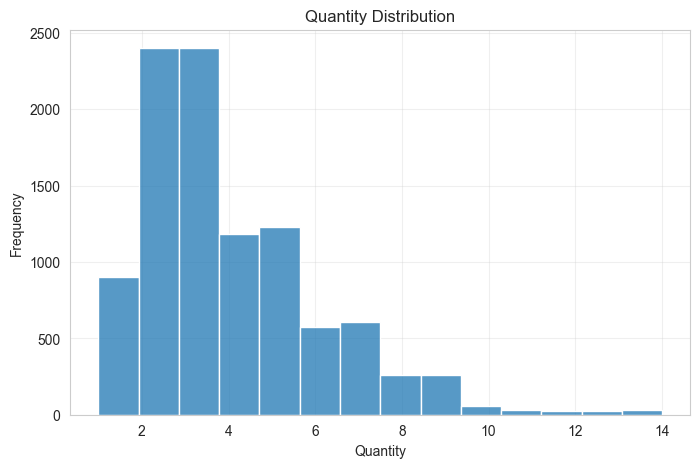

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=14)

plt.title("Quantity Distribution")

plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

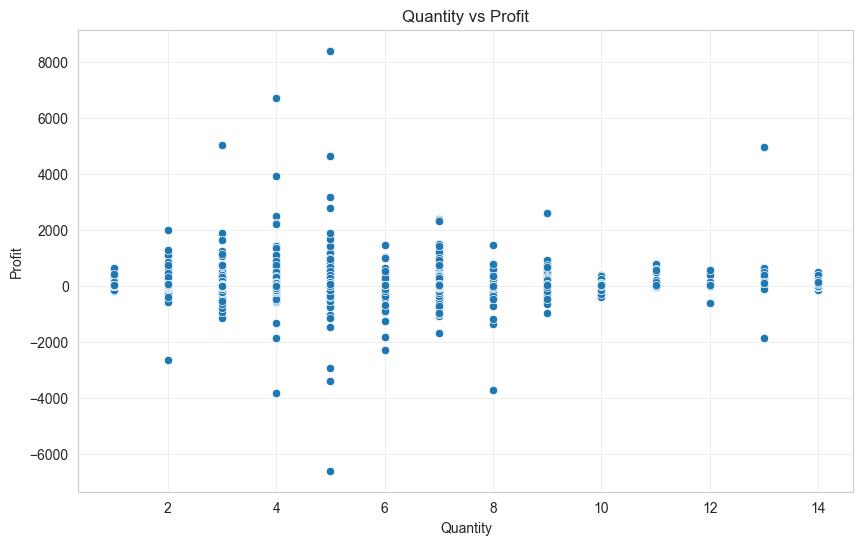

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Quantity',
    y='Profit',
    data=df
)

plt.title("Quantity vs Profit")

plt.xlabel("Quantity")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

In [33]:
quantity_profit_corr = df[['Quantity', 'Profit']].corr()

print(quantity_profit_corr)

          Quantity    Profit
Quantity  1.000000  0.066211
Profit    0.066211  1.000000


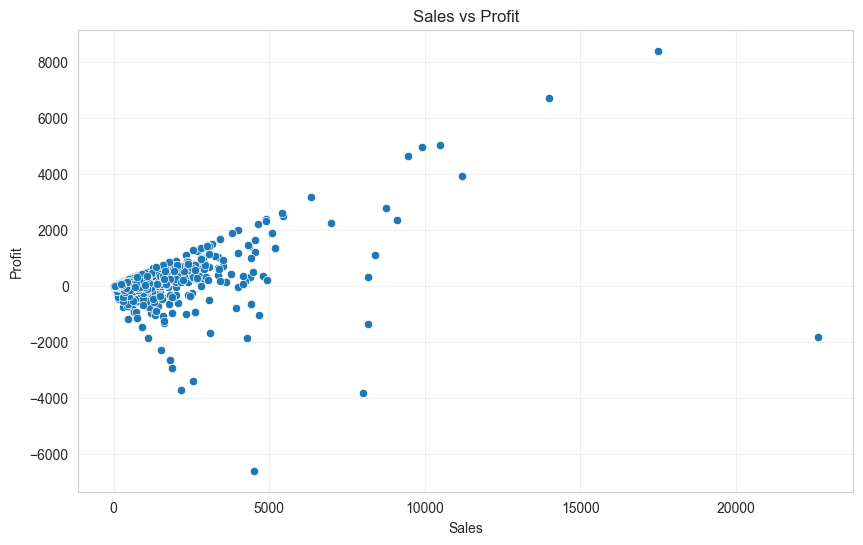

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Sales',
    y='Profit',
    data=df
)

plt.title("Sales vs Profit")

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

## Quantity and Sales Analysis

- Most customer orders were placed in small to medium quantities.
- Large quantity purchases were relatively uncommon.
- Quantity showed only a weak positive correlation with profit.
- Higher quantity sales do not necessarily guarantee higher profitability.
- Sales and profit generally show a positive relationship, but several high-sales transactions generated negative profit.
- The presence of loss-making high-revenue transactions suggests pricing or discount-related inefficiencies.

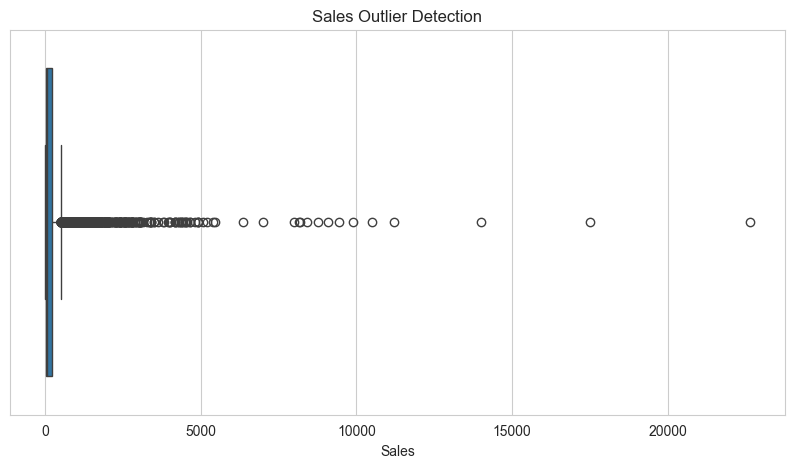

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Sales'])

plt.title("Sales Outlier Detection")

plt.show()

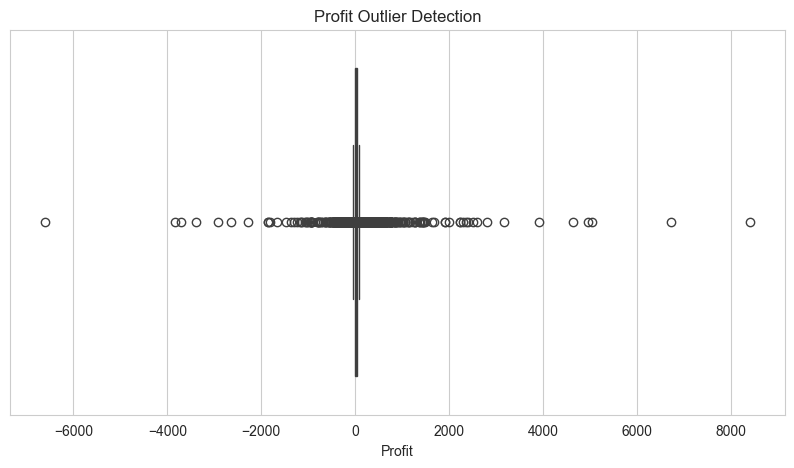

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Profit'])

plt.title("Profit Outlier Detection")

plt.show()

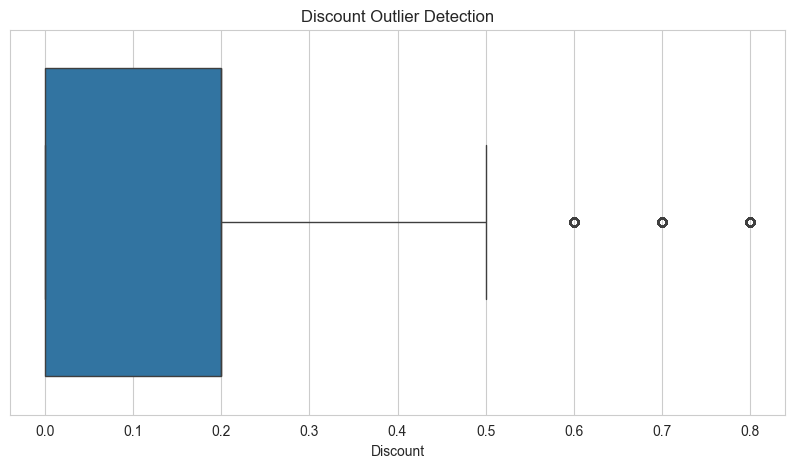

In [37]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Discount'])

plt.title("Discount Outlier Detection")

plt.show()

## Outlier Detection Analysis

- Sales data contains several extreme high-value transactions, indicating the presence of premium orders.
- Profit distribution includes both high positive profits and significant negative losses.
- The dataset shows strong skewness due to the presence of outliers.
- Discount values are mostly concentrated at lower levels, while extreme discounts (0.6–0.8) appear as outliers.
- High discount outliers are likely contributing to negative profitability in certain transactions.

In [38]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

             Postal Code     Sales  Quantity  Discount    Profit
Postal Code     1.000000 -0.023476  0.013110  0.059225 -0.029892
Sales          -0.023476  1.000000  0.200722 -0.028311  0.479067
Quantity        0.013110  0.200722  1.000000  0.008678  0.066211
Discount        0.059225 -0.028311  0.008678  1.000000 -0.219662
Profit         -0.029892  0.479067  0.066211 -0.219662  1.000000


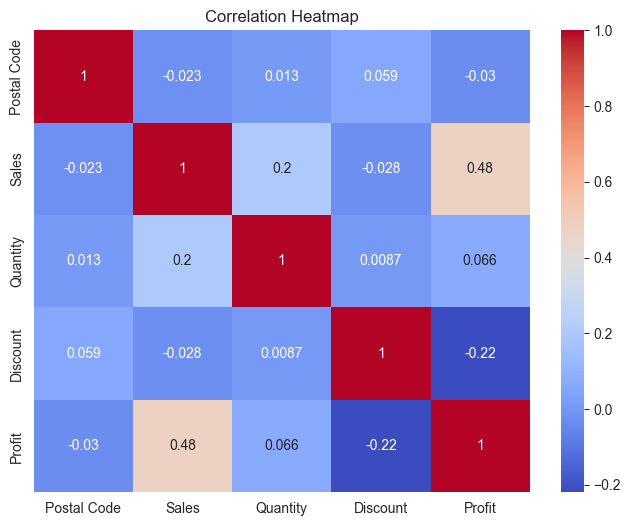

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

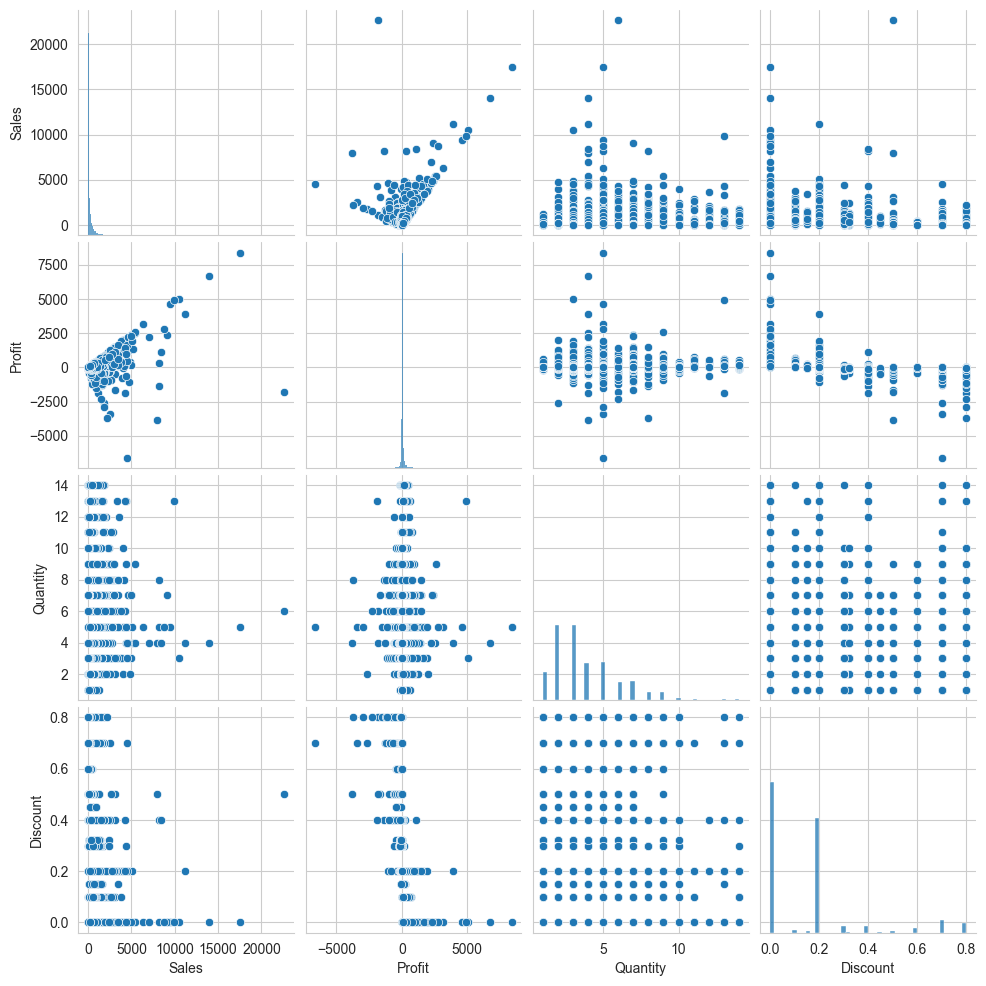

In [40]:
sns.pairplot(
    df[['Sales', 'Profit', 'Quantity', 'Discount']]
)

plt.show()

## Correlation and Pairplot Analysis

- Sales and Profit showed a moderate positive correlation (0.48), indicating that higher sales generally contribute to higher profit.
- Discount and Profit displayed a negative correlation (-0.22), confirming that excessive discounting reduces profitability.
- Quantity had only a weak relationship with profit, suggesting that bulk orders are not always highly profitable.
- Postal Code showed almost no meaningful relationship with business performance metrics.
- Pairplot analysis further confirmed the presence of outliers and the impact of discounts on profitability.